**Consider a random function of the form:**

y = mx + c 

**Import Libraries**

In [32]:
import numpy as np
import random


**Generate Linear Data with Gaussian Noise**

In [33]:
def generate_linear_data(x_values, num_points, slope, intercept, noise_mean, noise_std):

    # Step 1 — Generate random noise from a normal distribution
    noise = np.random.normal(noise_mean, noise_std, num_points)

    # Step 2 — Apply linear equation y = mx + c
    # Then add noise to simulate real-world imperfect data
    y_values = slope * x_values + intercept + noise

    # Step 3 — Return generated y values
    return y_values

**Compute Slope and Intercept (Simple Linear Regression)**

In [34]:

def linear_regression_coefficients(x_vals, y_vals):

    # Step 1 — Calculate mean of x and y
    x_mean = np.mean(x_vals)
    y_mean = np.mean(y_vals)

    # Step 2 — Initialize numerator and denominator
    Total_num = 0
    Total_den = 0

    # Step 3 — Loop through each data point
    for i in range(min(len(x_vals), len(y_vals))):
        
        # Numerator: sum of (yi - y_mean) * xi
        Total_num = Total_num + ((y_vals[i] - y_mean) * x_vals[i])
        
        # Denominator: sum of (xi - x_mean) * xi
        Total_den = Total_den + ((x_vals[i] - x_mean) * x_vals[i])
    
    # Step 4 — Calculate slope
    w1 = Total_num / Total_den

    # Step 4 — Calculate intercept
    w0 = y_mean - (w1 * x_mean)

    return w1, w0
    
    

In [35]:

# Step 1 — Generate random input values
x_inputs = np.random.random(100)

# Step 2 — Generate output data from the true model (no noise)
y = generate_linear_data(x_inputs, 100, 1.5, 3, 0, 0)

# Step 3 — Generate output data with noise (Std changed)
yn_std = generate_linear_data(x_inputs, 100, 1.5, 3, 0, 0.5)

# Step 4 — Generate output data with noise (Mean changed)
yn_mean = generate_linear_data(x_inputs, 100, 1.5, 3, 2, 0)

# Step 5 — Estimate slope and intercept from perfect data
w1, w0 = linear_regression_coefficients(x_inputs, y)

# Step 6 — Estimate slope and intercept from noisy data (Std changed)
w1_std, w0_std = linear_regression_coefficients(x_inputs, yn_std)

# Step 7 — Estimate slope and intercept from noisy data (Std changed)
w1_mean, w0_mean = linear_regression_coefficients(x_inputs, yn_mean)

# Step 8 — Print Actual parameters
print("Actual estimates:", round(w1, 2), (round(w0, 2))) # Actual slope & intercept for perfect data

# Step 9 — Print Estimated parameters (Std changed)
print("Noisy estimates change in Std:", round(w1_std, 2), (round(w0_std, 2))) # Estimated slope & intercept for perfect data

# Step 10 — Print estimated parameters (Mean changed)
print("Noisy estimates change in Mean:", round(w1_mean, 2), (round(w0_mean, 2))) # Estimated slope & intercept for perfect data


Actual estimates: 1.5 3.0
Noisy estimates change in Std: 1.43 3.08
Noisy estimates change in Mean: 1.5 5.0


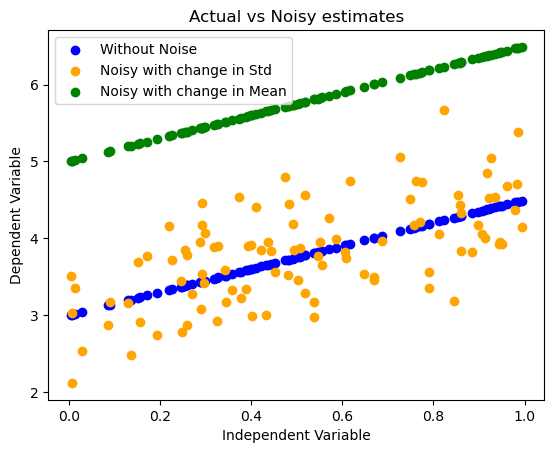

In [36]:
import matplotlib.pyplot as plt
plt.scatter(x_inputs, y, color='blue', label='Without Noise')
plt.scatter(x_inputs, yn_std, color='orange', label='Noisy with change in Std')
plt.scatter(x_inputs, yn_mean, color='green', label='Noisy with change in Mean')
plt.xlabel("Independent Variable")
plt.ylabel("Dependent Variable")
#plt.yscale(3)
plt.title("Actual vs Noisy estimates")
plt.legend()
plt.show()

***Standard Deviation vs Slope***

In [37]:
noise_levels = [0.1, 1, 5, 10, 20]
m_differ_collect = [] # Actual vs Noisy slopes collection
c_differ_collect = [] # Actual vs Noisy intercepts collection

# Generate x values
xm = np.random.random(10000)

# True model parameters
m = 1.5
c = 3

# Noise settings
num_points = 10000
noise_mean = 0

for noise_std in noise_levels:

    # Generate y values with current noise level
    y_noisy = generate_linear_data(xm, num_points, m, c, noise_mean, noise_std)

    # Generate y values with no noise (perfect line)
    y_perfect = generate_linear_data(xm, num_points, m, c, noise_mean, 0)

    # Estimate slope and intercept from noisy data
    m_est_noisy, c_est_noisy = linear_regression_coefficients(xm, y_noisy)

    # Estimate slope and intercept from perfect data
    m_est_perfect, c_est_perfect = linear_regression_coefficients(xm, y_perfect)

    # Calculate difference in slopes & intercepts
    m_difference = m_est_perfect - m_est_noisy
    c_difference = c_est_perfect - c_est_noisy

    # Store differences in slopes & intercepts
    m_differ_collect.append(m_difference)
    c_differ_collect.append(c_difference)

    print("Noise std with mean as zero:", noise_std)
    print("Noisy estimates   ->", round(m_est_noisy, 2), round(c_est_noisy, 2))
    print("Perfect estimates ->", round(m_est_perfect, 2), round(c_est_perfect, 2))
    print("Mp - Mn->", round(m_difference, 2))
    print("Cp - Cn->", round(c_difference, 2))
    print()

Noise std with mean as zero: 0.1
Noisy estimates   -> 1.5 3.0
Perfect estimates -> 1.5 3.0
Mp - Mn-> -0.0
Cp - Cn-> 0.0

Noise std with mean as zero: 1
Noisy estimates   -> 1.48 2.99
Perfect estimates -> 1.5 3.0
Mp - Mn-> 0.02
Cp - Cn-> 0.01

Noise std with mean as zero: 5
Noisy estimates   -> 1.53 3.15
Perfect estimates -> 1.5 3.0
Mp - Mn-> -0.03
Cp - Cn-> -0.15

Noise std with mean as zero: 10
Noisy estimates   -> 0.91 3.27
Perfect estimates -> 1.5 3.0
Mp - Mn-> 0.59
Cp - Cn-> -0.27

Noise std with mean as zero: 20
Noisy estimates   -> 0.9 3.28
Perfect estimates -> 1.5 3.0
Mp - Mn-> 0.6
Cp - Cn-> -0.28



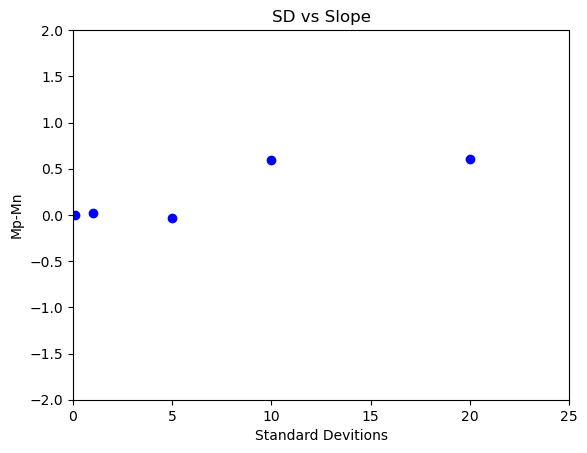

In [38]:

import matplotlib.pyplot as plt
plt.scatter(noise_levels, m_differ_collect, color='blue')
#plt.scatter(, yn, color='orange', label='With Noise')
plt.xlabel("Standard Devitions")
plt.ylabel("Mp-Mn")
plt.xlim(0, 25)
plt.ylim(-2, 2)
#plt.xscale(log)
plt.title("SD vs Slope")
#plt.legend()
plt.show()

***Mean vs Slope***

In [41]:
import numpy as np

mean_levels = [0.1, 1, 5, 10, 20]
slope_differ_collect_mean = [] # Actual vs Noisy slopes collection
intercept_differ_collect_mean = [] # Actual vs Noisy intercepts collection

# Generate x values
xmean = np.random.random(10000)

# True model parameters
m_mean = 1.5
c_mean = 3

# Noise settings
n_points = 10000
noise_stdev = 0

for noise_m in mean_levels:

    # Generate y values with current noise level
    y_noisy_mean = generate_linear_data(xmean, n_points, m_mean, c_mean, noise_m, noise_stdev)

    # Generate y values with no noise (perfect line)
    y_perfect_mean = generate_linear_data(xmean, n_points, m_mean, c_mean, 0, noise_stdev)

    # Estimate slope and intercept from noisy data
    slope_noisy, intercept_noisy = linear_regression_coefficients(xmean, y_noisy_mean)

    # Estimate slope and intercept from perfect data
    slope_perfect, intercept_perfect = linear_regression_coefficients(xmean, y_perfect_mean)
    
    # Calculate difference in slopes & intercepts
    slope_difference = slope_perfect - slope_noisy
    intercept_difference = intercept_perfect - intercept_noisy
    
    # Store differences in slopes & intercepts
    slope_differ_collect_mean.append(slope_difference)
    intercept_differ_collect_mean.append(intercept_difference)

    print("Noise_mean with std as zero:", noise_m)
    print("Noisy estimates   ->", round(slope_noisy, 2), round(intercept_noisy, 2))
    print("Perfect estimates ->", round(slope_perfect, 2), round(intercept_perfect, 2))
    print("Mp - Mn->", round(slope_difference, 2))
    print("Cp - Cn->", round(intercept_difference, 2))
    print()

Noise_mean with std as zero: 0.1
Noisy estimates   -> 1.5 3.1
Perfect estimates -> 1.5 3.0
Mp - Mn-> 0.0
Cp - Cn-> -0.1

Noise_mean with std as zero: 1
Noisy estimates   -> 1.5 4.0
Perfect estimates -> 1.5 3.0
Mp - Mn-> 0.0
Cp - Cn-> -1.0

Noise_mean with std as zero: 5
Noisy estimates   -> 1.5 8.0
Perfect estimates -> 1.5 3.0
Mp - Mn-> -0.0
Cp - Cn-> -5.0

Noise_mean with std as zero: 10
Noisy estimates   -> 1.5 13.0
Perfect estimates -> 1.5 3.0
Mp - Mn-> 0.0
Cp - Cn-> -10.0

Noise_mean with std as zero: 20
Noisy estimates   -> 1.5 23.0
Perfect estimates -> 1.5 3.0
Mp - Mn-> -0.0
Cp - Cn-> -20.0



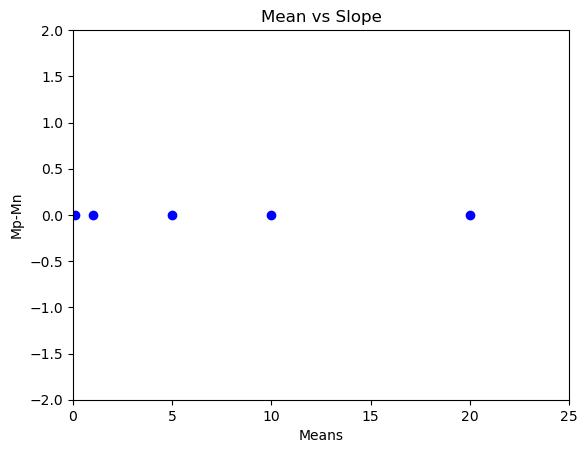

In [40]:

import matplotlib.pyplot as plt
plt.scatter(mean_levels, slope_differ_collect_mean, color='blue')
#plt.scatter(, yn, color='orange', label='With Noise')
plt.xlabel("Means")
plt.ylabel("Mp-Mn")
plt.xlim(0, 25)
plt.ylim(-2, 2)
#plt.xscale(log)
plt.title("Mean vs Slope")
#plt.legend()
plt.show()